In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("heart_disease_uci.csv")

In [7]:
df.head()
df.describe()
df.shape

(920, 16)

In [10]:
df.isnull().sum() #to check if any null values are present or not

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [15]:
df.drop("id", axis=1, inplace=True)

In [16]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [18]:
#target -> num cuz limited value like 0, 1,  2, 3, 4 only can be change into binary
df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0) 

In [19]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [26]:
from sklearn.impute import SimpleImputer

#numerical columns:-
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca", "num"]
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_cols = ["fbs", "restecg", "exang", "slope", "thal"]
cat_imputer = SimpleImputer(strategy = "most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [27]:
df.isnull().sum()

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

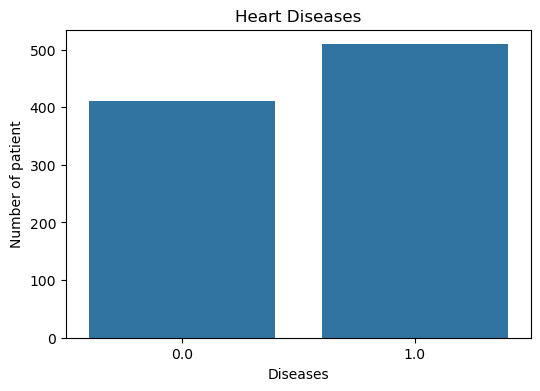

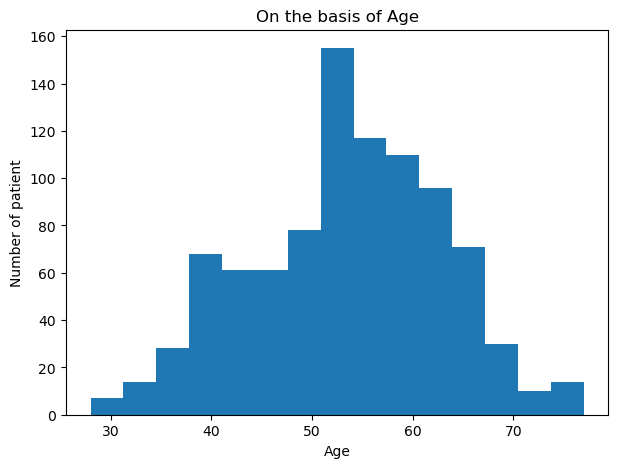

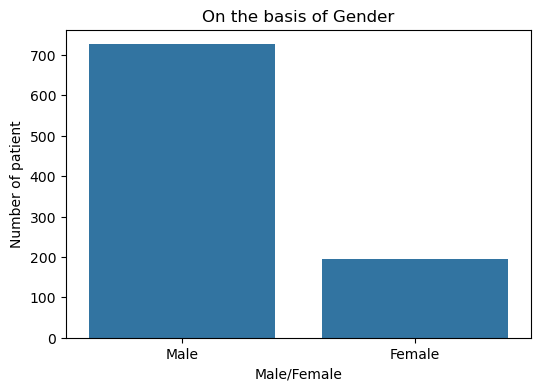

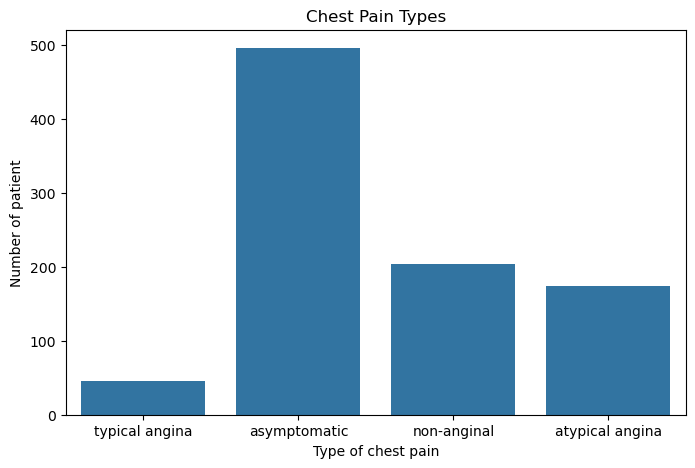

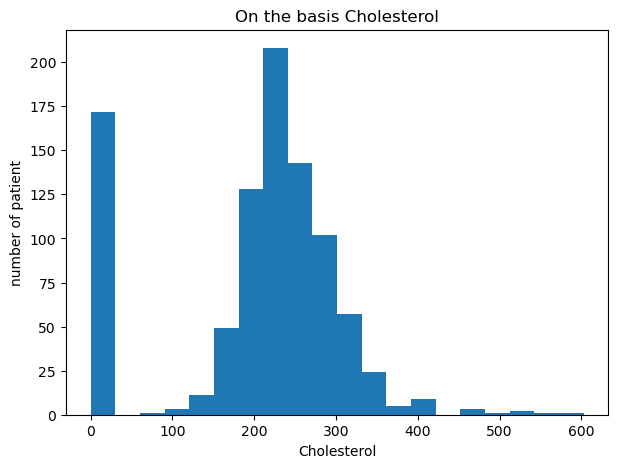

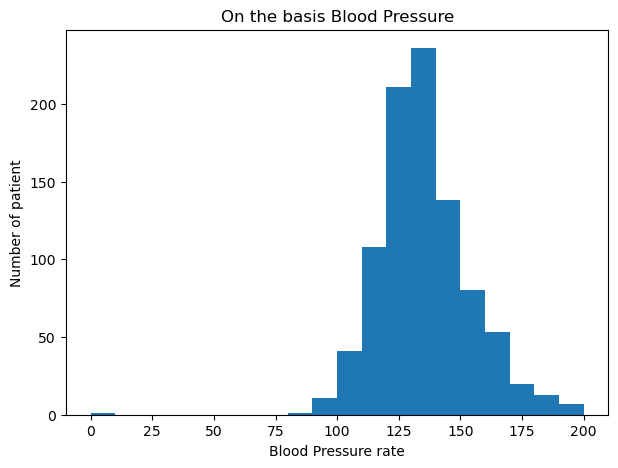

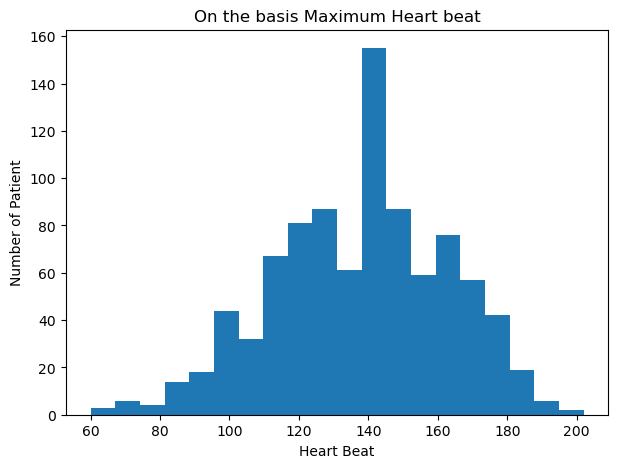

In [37]:
#graph:-
#on the basis of nums:-
plt.figure(figsize = (6, 4))
sns.countplot(x = "num", data = df)

plt.title("Heart Diseases")
plt.xlabel("Diseases")
plt.ylabel("Number of patient")

#on the basis of age:-
plt.figure(figsize = (7, 5))
plt.hist(df["age"], bins = 15)
plt.title("On the basis of Age")
plt.xlabel("Age")
plt.ylabel("Number of patient")

#on the basis of gneder
plt.figure(figsize = (6,4))
sns.countplot(x = "sex", data = df)
plt.title("On the basis of Gender")
plt.xlabel("Male/Female")
plt.ylabel("Number of patient")

#on the basis of chest pain
plt.figure(figsize=(8,5))
sns.countplot(x="cp", data=df)
plt.title("Chest Pain Types")
plt.xlabel("Type of chest pain")
plt.ylabel("Number of patient")

#on the basis of cholestrol
plt.figure(figsize=(7,5))
plt.hist(df["chol"], bins=20)
plt.title("On the basis Cholesterol")
plt.xlabel("Cholesterol")
plt.ylabel("number of patient")

#on the basis of blood pressure
plt.figure(figsize=(7,5))
plt.hist(df["trestbps"], bins=20)
plt.title("On the basis Blood Pressure")
plt.xlabel("Blood Pressure rate")
plt.ylabel("Number of patient")

#On the basis of heart beat
plt.figure(figsize=(7,5))
plt.hist(df["thalch"], bins=20)
plt.title("On the basis Maximum Heart beat")
plt.xlabel("Heart Beat")
plt.ylabel("Number of Patient")

plt.show()

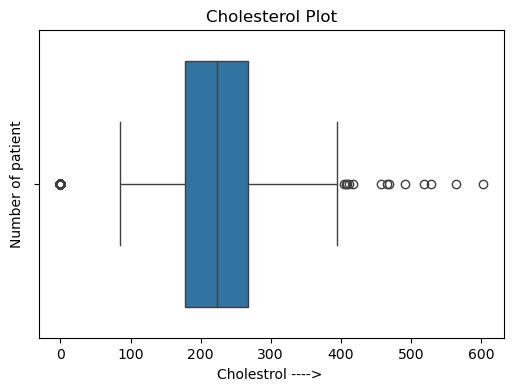

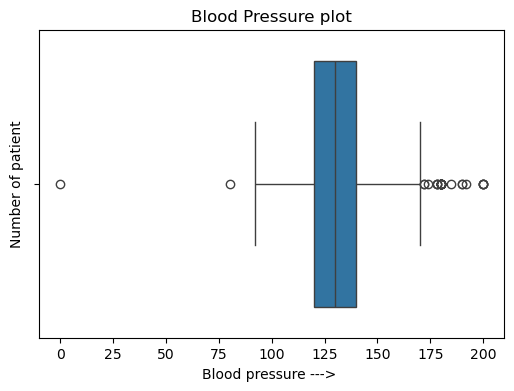

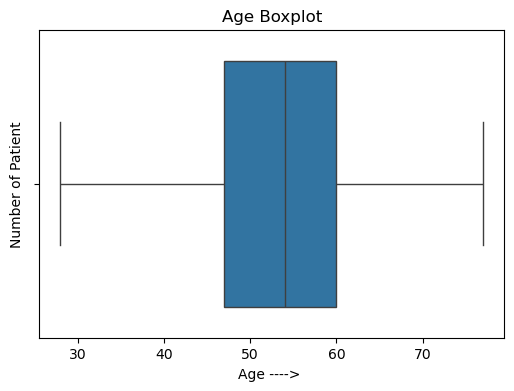

In [38]:
#Box plot:-
#plot for cholestrol
plt.figure(figsize=(6,4))
sns.boxplot(x=df["chol"])
plt.title("Cholesterol Plot")
plt.xlabel("Cholestrol ----> ")
plt.ylabel("Number of patient")

#plot for Blood pressure
plt.figure(figsize=(6,4))
sns.boxplot(x=df["trestbps"])
plt.title("Blood Pressure plot")
plt.xlabel("Blood pressure ---> ")
plt.ylabel("Number of patient")

#plot for age
plt.figure(figsize=(6,4))
sns.boxplot(x=df["age"])
plt.title("Age Boxplot")
plt.xlabel("Age ----> ")
plt.ylabel("Number of Patient")

plt.show()

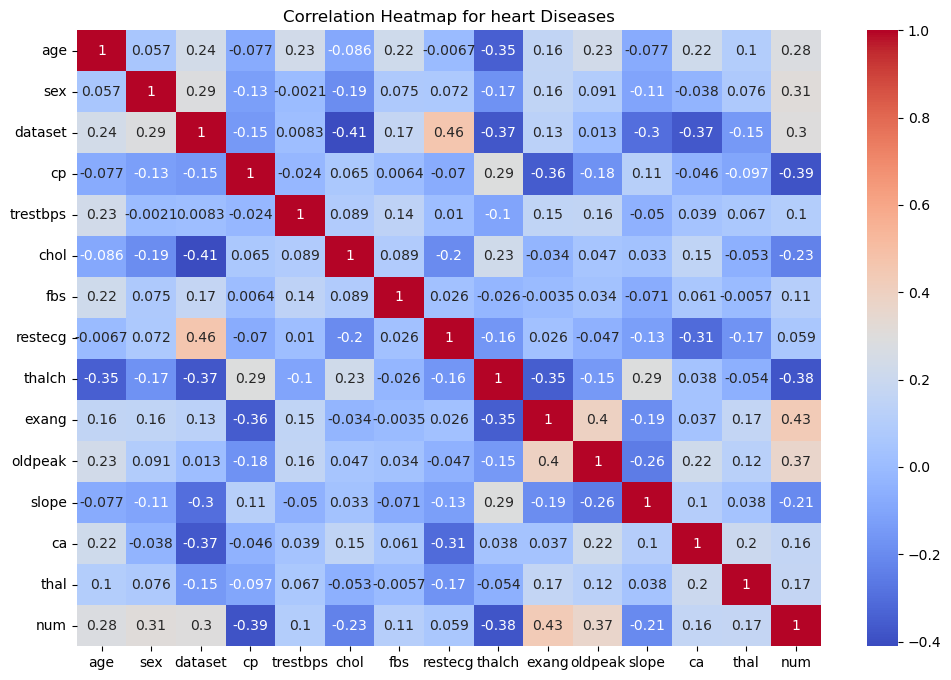

In [40]:
#catogorical column in number by heatmap
from sklearn.preprocessing import LabelEncoder

df_heat = df.copy()
le = LabelEncoder()

for col in df_heat.select_dtypes(include="object"):
    df_heat[col] = le.fit_transform(df_heat[col])

plt.figure(figsize=(12,8))
sns.heatmap(df_heat.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for heart Diseases")
plt.show()

In [42]:
df = pd.get_dummies(df, drop_first=True)
df.columns

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num', 'sex_Male',
       'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True',
       'restecg_normal', 'restecg_st-t abnormality', 'exang_True',
       'slope_flat', 'slope_upsloping', 'thal_normal',
       'thal_reversable defect'],
      dtype='object')

In [44]:
X = df.drop("num", axis=1)
y = df["num"]
print(X.shape)
print(y.shape)

(920, 21)
(920,)


In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(736, 21)
(184, 21)
(736,)
(184,)


In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
#regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [52]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [53]:
y_pred = model.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("Classification Report: ", classification_report(y_test, y_pred))

Accuracy : 0.8315217391304348
Precision : 0.8679245283018868
Recall : 0.8440366972477065
F1 Score : 0.8558139534883721
              precision    recall  f1-score   support

         0.0       0.78      0.81      0.80        75
         1.0       0.87      0.84      0.86       109

    accuracy                           0.83       184
   macro avg       0.82      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



In [56]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision :", precision_score(y_test, y_pred_dt))
print("Recall :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("Classification Report: ", classification_report(y_test, y_pred_dt))

Accuracy : 0.7717391304347826
Precision : 0.8383838383838383
Recall : 0.7614678899082569
F1 Score : 0.7980769230769231
Classification Report:                precision    recall  f1-score   support

         0.0       0.69      0.79      0.74        75
         1.0       0.84      0.76      0.80       109

    accuracy                           0.77       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.78      0.77      0.77       184



In [60]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("Classification Report: ", classification_report(y_test, y_pred_rf))

Accuracy : 0.842391304347826
Precision : 0.8773584905660378
Recall : 0.8532110091743119
F1 Score : 0.8651162790697674
Classification Report:                precision    recall  f1-score   support

         0.0       0.79      0.83      0.81        75
         1.0       0.88      0.85      0.87       109

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [61]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision :", precision_score(y_test, y_pred_knn))
print("Recall :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))
print("Classification Report: ", classification_report(y_test, y_pred_knn))

Accuracy : 0.8369565217391305
Precision : 0.8691588785046729
Recall : 0.8532110091743119
F1 Score : 0.8611111111111112
Classification Report:                precision    recall  f1-score   support

         0.0       0.79      0.81      0.80        75
         1.0       0.87      0.85      0.86       109

    accuracy                           0.84       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



In [62]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision :", precision_score(y_test, y_pred_svm))
print("Recall :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("Classification Report: ", classification_report(y_test, y_pred_svm))

Accuracy : 0.8586956521739131
Precision : 0.9029126213592233
Recall : 0.8532110091743119
F1 Score : 0.8773584905660378
Classification Report:                precision    recall  f1-score   support

         0.0       0.80      0.87      0.83        75
         1.0       0.90      0.85      0.88       109

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [64]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision :", precision_score(y_test, y_pred_gb))
print("Recall :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))
print("Classification Report: ", classification_report(y_test, y_pred_gb))

Accuracy : 0.8586956521739131
Precision : 0.9029126213592233
Recall : 0.8532110091743119
F1 Score : 0.8773584905660378
Classification Report:                precision    recall  f1-score   support

         0.0       0.80      0.87      0.83        75
         1.0       0.90      0.85      0.88       109

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [67]:
import joblib

joblib.dump(gb, "heart_disease_model.pkl")
joblib.dump(scaler, "heart_disease_scaler.pkl")

['heart_disease_scaler.pkl']

In [69]:
import os

print(os.listdir())
print(X.columns.tolist()) 

['.ipynb_checkpoints', 'credit_wise.ipynb', 'heart_disease.ipynb', 'heart_disease_model.pkl', 'heart_disease_scaler.pkl', 'heart_disease_uci.csv', 'loan_approval_dataset.csv', 'model.pkl', 'scaler.pkl', 'startup_dataset.csv', 'startup_project.ipynb', 'startup_success_model.pkl']
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Male', 'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']
